In [1]:
from graphs import generate_grid_graph, grid_graph_max_cut, grid_renderer, state_history_renderer, render_state, render_state_prog_gif
from cim import CIM
from solvers import SG3
from graphs import read_graph_from_rudy, eval_max_cut
from schedules import schedule_linear
from transfers import transfer_dict
import torch
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 10x10 Square Grids 

In [2]:
size = 10
J = generate_grid_graph(size)
max_cut = grid_graph_max_cut(size)
print(f"{max_cut=}")
pump_schedule=schedule_linear(slope=0.01, t_mid=50, max_val = 1.1)
noise_magnitude = 0.003
steps=5000
step_size=0.02

cim_list = []
for name, transfer in transfer_dict.items():
    cim = CIM(-0.1 * J, pump_schedule=pump_schedule, transfer=transfer)
    cim_list.append((name, cim))


max_cut=180


In [3]:
for name, cim in cim_list:
    torch.manual_seed(0xDEADBEEF + 0)
    cim.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
    print(f"=== {name} ===")
    print(cim.model.state)
    print("DOPO:", eval_max_cut(cim.model.state.tolist(), J))

=== TraditionalDOPO ===
tensor([-0.5646,  0.6337, -0.6385,  0.6407, -0.6397,  0.6400, -0.6396,  0.6359,
        -0.6333,  0.5666,  0.6331, -0.6947,  0.6997, -0.7045,  0.7009, -0.7039,
         0.7008, -0.7004,  0.6941, -0.6321, -0.6371,  0.6987, -0.7079,  0.7083,
        -0.7075,  0.7058, -0.7069,  0.7069, -0.7024,  0.6380,  0.6321, -0.6977,
         0.7034, -0.7090,  0.7033, -0.7058,  0.7064, -0.7058,  0.7050, -0.6402,
        -0.5566,  0.6783, -0.7060,  0.7084, -0.7063,  0.7033, -0.7049,  0.7076,
        -0.7003,  0.6417, -0.1256, -0.4952,  0.6803, -0.7092,  0.7083, -0.7045,
         0.7076, -0.7109,  0.7019, -0.6379,  0.5507, -0.3602, -0.6028,  0.6988,
        -0.7081,  0.7059, -0.7066,  0.7021, -0.7013,  0.6366, -0.6126,  0.5260,
         0.5768, -0.6949,  0.7052, -0.7083,  0.7058, -0.7083,  0.6999, -0.6401,
         0.6139, -0.5413, -0.5606,  0.6905, -0.7013,  0.7027, -0.6990,  0.7006,
        -0.6947,  0.6326, -0.5455,  0.4719,  0.4923, -0.6262,  0.6355, -0.6390,
         0.6357,

In [4]:
max_energy = max(map(max, [cim.model.result.energy_history for _, cim in cim_list]))
min_energy = min(map(min, [cim.model.result.energy_history for _, cim in cim_list]))
min_energy, max_energy

(tensor(-18.0000), tensor(-8.1000))

=== TraditionalDOPO ===
=== DOPO ===
=== FifthOrder ===
=== SNN ===
=== Clipped ===


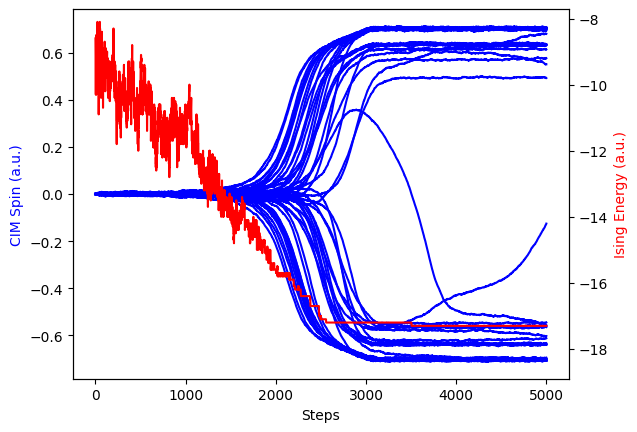

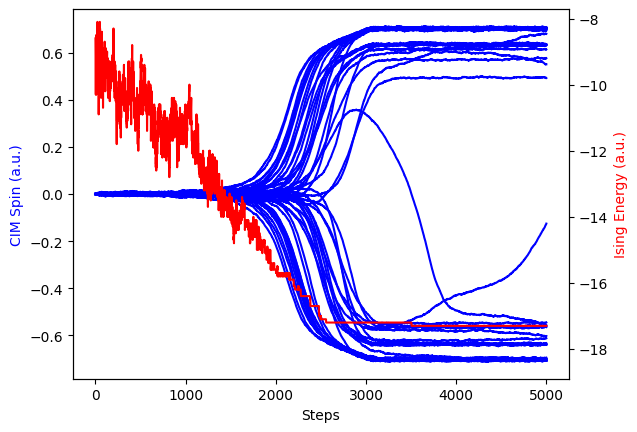

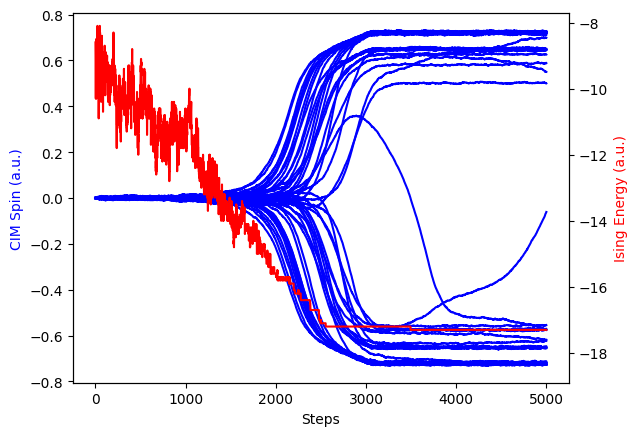

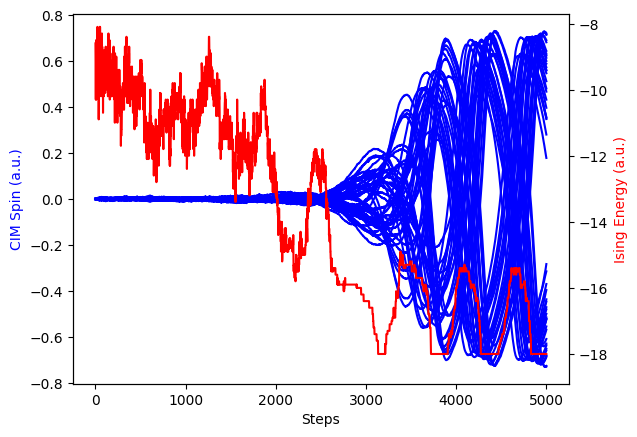

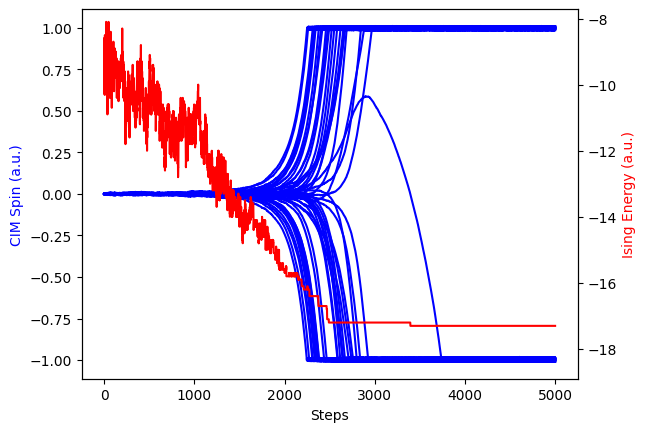

In [5]:
for name, cim in cim_list:
    print(f"=== {name} ===")
    print(f"{cim.solver.network.transfer}")
    
    
    fig, ax1 = plt.subplots()
    color='b'
    ax1.plot([state[::2] for state in cim.model.result.state_history], color=color)
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("CIM Spin (a.u.)", color=color)

    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    color = 'r'
    ax2.plot(cim.model.result.energy_history, color=color)
    ax2.set_ylim(min_energy*1.05, max_energy/1.05)
    ax2.set_ylabel('Ising Energy (a.u.)', color=color)
    
    fig.savefig(f'ims/02_transfers/{name}_CIM_{size}x{size}_SqLattice_States.png', dpi=900)

## N=80 BiqMac
scripts\biqmac\graphs\rudy\pm1s_80.0

g05_n.i For each dimension ten unweighted graphs with edge probability 0.5. n=60,80,100.
pm1s_n.i For each dimension ten weighted graphs with edge weights chosen uniformly from {-1,0,1} and density 0.1. n=80,100
pm1d_n.i For each dimension ten weighted graphs with edge weights chosen uniformly from {-1,0,1} and density 0.99. n=80,100
wd_100.i For each density ten graphs with integer edge weights chosen from [-10,10] and density d=0.1,0.5,0.9, n=100.
pwd_100.i For each density ten graphs with integer edge weights chosen from [0,10] and density d=0.1,0.5,0.9, n=100.

In [6]:
J = read_graph_from_rudy("../scripts/biqmac/graphs/rudy/pm1s_80.0")
max_cut = 79  # TODO: Make maxcut lookup automatic
print(f"{max_cut=}")
pump_schedule=schedule_linear(slope=0.01, t_mid=50, max_val = 1.1)
noise_magnitude = 0.003
steps=5000
step_size=0.02

cim_list = []
for name, transfer in transfer_dict.items():
    cim = CIM(-0.1 * J, pump_schedule=pump_schedule, transfer=transfer)
    cim_list.append((name, cim))

max_cut=79


In [9]:
for name, cim in cim_list:
    torch.manual_seed(0xDEADBEEF + 0)
    cim.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
    print(f"=== {name} ===")
    print(cim.model.state)
    print("DOPO:", eval_max_cut(cim.model.result.minimum_energy_state, J))

In [ ]:
max_energy = max(map(max, [cim.model.result.energy_history for _, cim in cim_list]))
min_energy = min(map(min, [cim.model.result.energy_history for _, cim in cim_list]))
min_energy, max_energy

In [ ]:
for name, cim in cim_list:
    print(f"=== {name} ===")
    print(f"{cim.solver.network.transfer}")
    
    
    fig, ax1 = plt.subplots()
    color='b'
    ax1.plot([state[::2] for state in cim.model.result.state_history], color=color)
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("CIM Spin (a.u.)", color=color)

    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    color = 'r'
    ax2.plot(cim.model.result.energy_history, color=color)
    ax2.set_ylim(min_energy*1.05, max_energy/1.05)
    ax2.set_ylabel('Ising Energy (a.u.)', color=color)
    
    fig.savefig(f'ims/02_transfers/{name}_CIM_{size}x{size}_pm1s_80.0_States.png', dpi=900)